<!-- reader-content -->

# Energy-participation quantization

A field solver can simulate a superconducting layout with each Josephson
junction replaced by its linear inductance. The eigenmodes, and the fraction of
each mode's inductive energy stored in each junction, determine the circuit
Hamiltonian ([Minev et al., 2021](https://doi.org/10.1038/s41534-021-00461-8)).
pyEPR and Quantum Metal compute these energy-participation ratios (EPRs) for
Ansys HFSS designs. How accurate is the first-order Hamiltonian that summarizes
them, and does its error matter for readout?

A lumped transmon–resonator circuit stands in for the field solver here. Its
linear modes are exact, so every EPR result can be checked against the circuit
itself. Frequencies are in GHz, times in ns and inductances in H.

In the basis of linear modes with frequencies $f_m$,

```{math}
H/h = \sum_m f_m a_m^\dagger a_m
      - \sum_j E_{J,j}\left[\cos\hat\varphi_j - 1 + \hat\varphi_j^2/2\right],
\qquad
\hat\varphi_j = \sum_m s_{mj}\sqrt{\frac{p_{mj} f_m}{2E_{J,j}}}\,(a_m + a_m^\dagger),
```

where $p_{mj}$ is the participation of junction $j$ in mode $m$, $s_{mj}$ its
sign, and $E_{J,j}$ the Josephson energy of its linear inductance. The
quadratic part of each junction potential is already in $f_m$.

## Describe the circuit by its modes

A transmon node (junction $L_J$, capacitance $C_q$) couples through $C_g$ to a
readout resonator ($L_r$, $C_r$). The modes solve $L^{-1}v = \omega^2 C v$.
Junction $j$ holds the fraction $p_{mj} = \Phi_{mj}^2/(L_J\omega_m^2)$ of mode
$m$'s inductive energy, where $\Phi_{mj}$ is its branch flux in the
$C$-normalized mode. The quality factors stand in for the field solver's
eigenmode Qs: a qubit mode limited by intrinsic loss and a readout mode limited
by its output port.

In [1]:
import numpy as np
import scipy.linalg as sla

from quchip import EPRModel

c_q, c_r, c_g = 90e-15, 400e-15, 6e-15  # F
l_r = 1.2e-9  # H
capacitance = np.array([[c_q + c_g, -c_g], [-c_g, c_r + c_g]])


def lumped_epr(l_j):
    """Return the EPR model of the circuit for junction inductance l_j in H."""
    omega2, modes = sla.eigh(np.diag([1 / l_j, 1 / l_r]), capacitance)
    junction_flux = modes[0]  # transmon node flux in each C-normalized mode
    return EPRModel(
        freqs=np.sqrt(omega2) / (2 * np.pi * 1e9),
        participations=(junction_flux**2 / (l_j * omega2))[:, None],
        signs=np.sign(junction_flux)[:, None],
        junction_inductances=[l_j],
        labels=["q", "r"],
        quality_factors=[2.0e6, 1.5e4],
    )


epr = lumped_epr(11e-9)
for m, label in enumerate(epr.labels):
    print(f"{label}: f = {epr.freqs[m]:.6f} GHz, p = {epr.participations[m, 0]:.6f}, "
          f"|phi_zpf| = {abs(epr.phi_zpf[m, 0]):.6f}")

q: f = 4.895721 GHz, p = 0.998538, |phi_zpf| = 0.405568
r: f = 7.216700 GHz, p = 0.001462, |phi_zpf| = 0.018844


The readout mode stores 0.15% of its inductive energy in the junction, which
sets its dispersive coupling to the qubit. The eigensolver fixes each mode's
overall sign; signs matter only relative to other junctions.

## Compare the Hamiltonians

`chip(levels=...)` builds the Hamiltonian pyEPR diagonalizes numerically: the
modes stay linear and the junction term enters exactly. With
`nonlinearity="first_order"`, it builds pyEPR's first-order Hamiltonian
instead: one Duffing mode per eigenmode and one cross-Kerr coupling per pair.
The reference is the same circuit in its node basis: a charge-basis transmon
coupled to an oscillator through $C^{-1}_{qr}Q_qQ_r$.

In [2]:
from scipy.constants import e, h, hbar

from quchip import Capacitive, ChargeBasisTransmon, Chip, Exact, Resonator

first = epr.chip(levels={"q": 3, "r": 12}, nonlinearity="first_order")
full = epr.chip(levels={"q": 20, "r": 8})

inverse = np.linalg.inv(capacitance)
omega_r = np.sqrt(inverse[1, 1] / l_r)
charge_zpf = np.sqrt(hbar * omega_r / (2 * inverse[1, 1]))
transmon = ChargeBasisTransmon(
    E_C=e**2 * inverse[0, 0] / (2 * h * 1e9),
    E_J=float(epr.junction_energies[0]),
    n_g=0.25, num_basis=31, levels=8, label="q",
)
readout = Resonator(freq=omega_r / (2 * np.pi * 1e9), levels=8, label="r")
g = inverse[0, 1] * 2 * e * charge_zpf / (h * 1e9)  # GHz, charge-charge coupling
coupling = Capacitive(transmon, readout, g=g, label="qr")
circuit = Chip([transmon, readout], [coupling], approximation=Exact())


def dressed(chip):
    """Return the dressed qubit frequency, anharmonicity and dispersive shift in GHz."""
    kerr = chip.kerr_matrix()
    return np.array([chip.freq("q"), kerr["q", "q"], kerr["q", "r"]], dtype=float)


rows = [f"{'':>11}  f_q (GHz)  alpha (MHz)  chi (MHz)"]
for name, chip in (("first order", first), ("cosine", full), ("circuit", circuit)):
    f_q, alpha, chi = dressed(chip)
    rows.append(f"{name:>11}  {f_q:9.6f}  {1e3 * alpha:11.3f}  {1e3 * chi:9.4f}")
print("\n".join(rows))

             f_q (GHz)  alpha (MHz)  chi (MHz)
first order   4.694263     -201.025    -0.8679
     cosine   4.684862     -224.448    -0.7449
    circuit   4.684862     -224.448    -0.7449


`kerr_matrix()` returns anharmonicities on the diagonal and full-pull
cross-Kerr shifts $E_{11}-E_{10}-E_{01}+E_{00}$ off it. pyEPR prints the same
first-order matrix as `chi_O1`, in MHz and with the opposite sign. The cosine
chip reproduces the circuit to its Fock truncation. First order places the
qubit 9 MHz too high, underestimates $|\alpha|$ by 10% and overestimates
$|\chi|$ by 17%.

## Sweep the junction inductance

A layout study sweeps the junction inductance, Quantum Metal's default EPR sweep
variable. Each inductance is a new eigenmode simulation, so the modes are solved
again. The node-basis reference changes only $E_J$, which `with_params()` sets
on a copy. The compact transmon also depends on its offset charge $n_g$;
evaluate it at $n_g = 0$, $1/4$ and $1/2$.

In [3]:
inductances = np.linspace(8e-9, 20e-9, 13)
offsets = (0.0, 0.25, 0.5)

first_order, cosine, reference = [], [], {offset: [] for offset in offsets}
for l_j in inductances:
    model = lumped_epr(l_j)
    first_order.append(dressed(model.chip(levels=3, nonlinearity="first_order")))
    cosine.append(dressed(model.chip(levels={"q": 20, "r": 8})))
    josephson = float(model.junction_energies[0])
    for offset in offsets:
        point = circuit.with_params({"q.E_J": josephson, "q.n_g": offset})
        reference[offset].append(dressed(point))

first_order, cosine = np.array(first_order), np.array(cosine)
reference = {offset: np.array(values) for offset, values in reference.items()}
exact = reference[0.25]

<details>
<summary>Plot the sweep</summary>

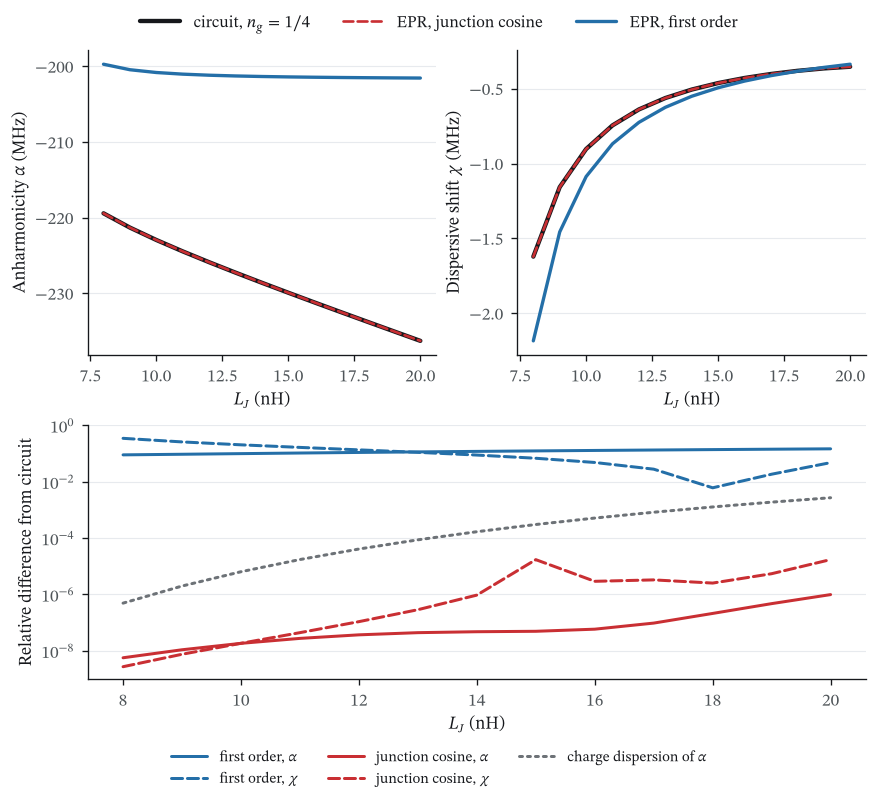

In [4]:
import shutil
import matplotlib.pyplot as plt

plt.style.use("../docs/_static/quchip.mplstyle")
plt.rcParams["text.usetex"] = bool(shutil.which("latex"))

ink, red, blue, soft = "#16181C", "#C92F33", "#246FA8", "#6D7277"
inductance_nh = 1e9 * inductances
sweep_figure, axes = plt.subplot_mosaic(
    [["alpha", "chi"], ["error", "error"]],
    figsize=(7.2, 6.6),
    height_ratios=(1.2, 1.0),
    layout="constrained",
)

for key, column, ylabel in (
    ("alpha", 1, r"Anharmonicity $\alpha$ (MHz)"),
    ("chi", 2, r"Dispersive shift $\chi$ (MHz)"),
):
    axis = axes[key]
    axis.plot(inductance_nh, 1e3 * exact[:, column], color=ink, linewidth=2.6,
              label=r"circuit, $n_g = 1/4$")
    axis.plot(inductance_nh, 1e3 * cosine[:, column], color=red, linewidth=1.6, linestyle="--",
              label="EPR, junction cosine")
    axis.plot(inductance_nh, 1e3 * first_order[:, column], color=blue, linewidth=2.0,
              label="EPR, first order")
    axis.set(xlabel=r"$L_J$ (nH)", ylabel=ylabel)
handles, labels = axes["alpha"].get_legend_handles_labels()
sweep_figure.legend(handles, labels, loc="outside upper center", ncols=3)

error_styles = (
    (first_order, 1, blue, "-", r"first order, $\alpha$"),
    (first_order, 2, blue, "--", r"first order, $\chi$"),
    (cosine, 1, red, "-", r"junction cosine, $\alpha$"),
    (cosine, 2, red, "--", r"junction cosine, $\chi$"),
)
for values, column, color, linestyle, label in error_styles:
    relative = np.maximum(np.abs(values[:, column] / exact[:, column] - 1), 1e-9)
    axes["error"].semilogy(inductance_nh, relative, color=color, linestyle=linestyle,
                           linewidth=1.8, label=label)
dispersion = np.abs(reference[0.0][:, 1] - reference[0.5][:, 1]) / (2 * np.abs(exact[:, 1]))
axes["error"].semilogy(inductance_nh, dispersion, color=soft, linestyle=":", linewidth=1.8,
                       label=r"charge dispersion of $\alpha$")
axes["error"].set(xlabel=r"$L_J$ (nH)", ylabel="Relative difference from circuit",
                  ylim=(1e-9, 1.0))
handles, labels = axes["error"].get_legend_handles_labels()
sweep_figure.legend(handles, labels, loc="outside lower center", ncols=3, fontsize=9)

sweep_path = "../docs/images/energy_participation_sweep.svg"
sweep_figure.savefig(sweep_path)
plt.show()

</details>

```{figure} ../images/energy_participation_sweep.svg
:alt: Anharmonicity and dispersive shift against junction inductance for first-order EPR, junction-cosine EPR and the node-basis circuit, with their relative differences on a logarithmic scale.

First-order EPR misses the anharmonicity by 9–15% across the sweep. Its
dispersive-shift error runs from +35% to −5% and changes sign near 18 nH, so
it is not a fixed offset. The junction-cosine chip follows the circuit at
$n_g = 1/4$ to better than $2\times10^{-5}$. The dotted line is the circuit's
relative spread in $\alpha$ between $n_g = 0$ and $1/2$.
[PDF](../images/energy_participation_sweep.pdf)
```

EPR treats the junction phase as an extended coordinate. It therefore has no
charge dispersion and reproduces the circuit at $n_g = 1/4$, where charge
dispersion cancels to first order. The circuit's anharmonicity varies with
offset charge by $\pm5\times10^{-7}$ of its value at $E_J/E_C = 101$ and by
$\pm0.3\%$ at $E_J/E_C = 40$: more than the cosine chip's truncation error,
far less than the first-order error.

## Read out the qubit

The first-order chip is diagonal, so it keeps its form in a rotating frame and
simulates quickly. Binding the cosine chip's dressed frequencies and Kerr
coefficients to the same model with `with_params()` gives a readout model of the
same cost. Each quality factor sets its mode's loss: the qubit relaxes with
$T_1 = Q_q/(2\pi f_q)$ and the resonator with $\kappa = 2\pi f_r/Q_r$. Pointer
states refer to a fixed qubit state, so the readout runs remove qubit
relaxation and keep the resonator loss. Drive the resonator midway between its
two conditional frequencies for 4 µs, once with the qubit in $|0\rangle$ and
once in $|1\rangle$.

In [5]:
from quchip import ChargeDrive, QuantumSequence, Square

kerr = full.kerr_matrix()
calibrated = first.with_params({
    "q.freq": full.freq("q"), "q.anharmonicity": kerr["q", "q"],
    "r.freq": full.freq("r"), "r.anharmonicity": kerr["r", "r"],
    "q_r.chi": kerr["q", "r"],
})

kappa = first["r"].intrinsic_decay_rate()  # 1/ns

amplitude, duration = 0.00125, 4000.0  # GHz, ns
times = np.linspace(0.0, duration, 801)
pointers, linear = {}, {}
for name, model in (("first order", first), ("junction cosine", calibrated)):
    carrier = float(model.freq("r", when={"q": 0}) + model.freq("r", when={"q": 1})) / 2
    chip = model.with_params({"q.T1": None})
    chip.set_frame({"q": chip.freq("q"), "r": carrier})
    line = ChargeDrive(chip["r"], label="readout")
    chip.wire(line)
    sequence = QuantumSequence(chip)
    pulse = Square(duration=duration, amplitude=amplitude)
    sequence.schedule(line, envelope=pulse, freq=carrier)
    branches = sequence.simulate_batch(
        sequence.vary("initial_state", [{"q": 0, "r": 0}, {"q": 1, "r": 0}]),
        tlist=times, e_ops=chip.e_ops(r=["a"]), states="none", progress=False,
    )
    pointers[name] = np.array([branch.expect("r", 0) for branch in branches])
    # The carrier is |chi|/2 from each conditional resonance. The rotating-wave
    # drive strength is pi * amplitude in rad/ns.
    detuning, drive = np.pi * abs(float(model.kerr_matrix()["q", "r"])), np.pi * amplitude
    linear[name] = 2 * drive * detuning / (detuning**2 + kappa**2 / 4)

linewidth = 1e3 * kappa / (2 * np.pi)  # MHz
lines = [
    f"qubit T1 = {first['q'].T1 / 1e3:.1f} us, readout linewidth = {linewidth:.3f} MHz",
    f"{'':>15}  separation  steady state  photons  rate (1/us)",
]
row = "{:>15}  {:10.3f}  {:12.3f}  {:7.2f}  {:11.2f}"
for name, fields in pointers.items():
    separation = abs(fields[0, -1] - fields[1, -1])
    photons = np.mean(np.abs(fields[:, -1]) ** 2)
    rate = 1e3 * kappa * separation**2 / 2
    lines.append(row.format(name, separation, linear[name], photons, rate))
print("\n".join(lines))

qubit T1 = 65.0 us, readout linewidth = 0.481 MHz
                 separation  steady state  photons  rate (1/us)
    first order       2.207         2.203     1.59         7.36
junction cosine       2.373         2.368     2.00         8.51


<details>
<summary>Plot the pointer separation</summary>

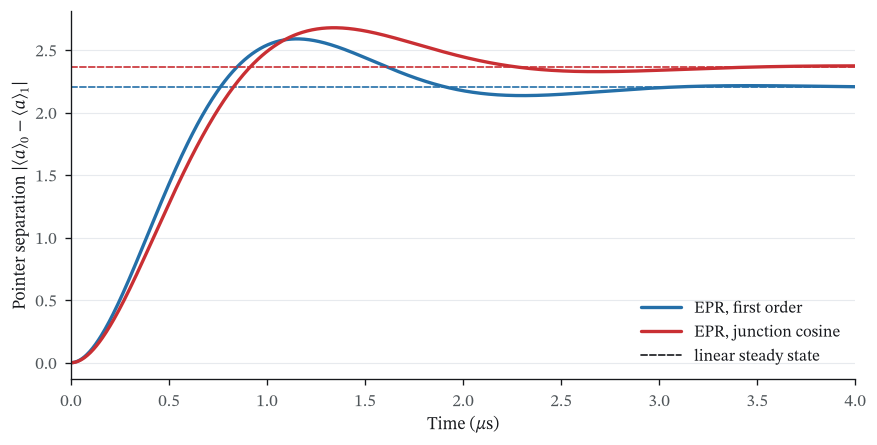

In [6]:
readout_figure, readout_axis = plt.subplots(figsize=(7.2, 3.6), layout="constrained")
for (name, fields), color in zip(pointers.items(), (blue, red)):
    separation = np.abs(fields[0] - fields[1])
    readout_axis.plot(1e-3 * times, separation, color=color, linewidth=2.0, label=f"EPR, {name}")
    readout_axis.axhline(linear[name], color=color, linewidth=1.0, linestyle="--")
readout_axis.plot([], [], color=ink, linewidth=1.0, linestyle="--",
                  label="linear steady state")
readout_axis.set(
    xlabel=r"Time ($\mu$s)",
    ylabel=r"Pointer separation $|\langle a\rangle_0 - \langle a\rangle_1|$",
    xlim=(0.0, 1e-3 * duration),
)
readout_axis.legend(loc="lower right")

readout_path = "../docs/images/energy_participation_readout.svg"
readout_figure.savefig(readout_path)
plt.show()

</details>

```{figure} ../images/energy_participation_readout.svg
:alt: Separation of the resonator fields conditioned on the qubit state against time during a 4 microsecond readout drive, for first-order and junction-cosine EPR models, with their linear steady states.

Separation of the resonator fields for the qubit in $|0\rangle$ and
$|1\rangle$. Both models ring up at the resonator linewidth and settle at the
linear dispersive steady state (dashed). With the same drive, the first-order
model separates the pointer states 7% less.
[PDF](../images/energy_participation_readout.pdf)
```

The drive sits half a dispersive shift from each conditional resonance. A
larger shift therefore detunes both further: the first-order model stores 1.6
rather than 2.0 photons and predicts a measurement rate
$\Gamma_m = \kappa|\alpha_0-\alpha_1|^2/2$ 14% below the junction-cosine
model at the same drive power.

## Check the calculation

The junction-cosine chip converges exponentially in Fock levels. Its change
from 16 to 20 qubit-mode levels at the longest inductance, where
$\varphi_{\mathrm{zpf}}$ is largest, bounds its truncation error; that bound
must lie far below the first-order error. After a drive of constant amplitude,
each pointer field approaches the linear steady state
$|\alpha_0 - \alpha_1| = 2\varepsilon\Delta/(\Delta^2 + \kappa^2/4)$ with
$\varepsilon = \pi A$ and $\Delta = \pi|\chi|$. The remaining ring-up transient,
$e^{-\kappa T/2}$, and the resonator self-Kerr shift over the linewidth set the
tolerance.

<details>
<summary>Numerical checks and record</summary>

In [7]:
import json

longest = lumped_epr(inductances[-1])
coarse, fine = (
    dressed(longest.chip(levels={"q": n, "r": 8}))[1:] for n in (16, 20)
)
truncation_bound = float(np.max(np.abs(fine / coarse - 1)))
cosine_error = float(np.max(np.abs(cosine[:, 1:] / exact[:, 1:] - 1)))
first_alpha_error = np.abs(first_order[:, 1] / exact[:, 1] - 1)
first_chi_error = first_order[:, 2] / exact[:, 2] - 1
charge_dispersion = float(np.max(
    np.abs(reference[0.0][:, 1] - reference[0.5][:, 1]) / (2 * np.abs(exact[:, 1]))
))

readout_record = {}
for name, model in (("first order", first), ("junction cosine", calibrated)):
    fields = pointers[name]
    separation = float(abs(fields[0, -1] - fields[1, -1]))
    photons = float(np.max(np.abs(fields[:, -1]) ** 2))
    kerr_shift = 2 * np.pi * abs(float(model.kerr_matrix()["r", "r"])) * photons  # rad/ns
    readout_record[name] = {
        "chi_mhz": 1e3 * abs(float(model.kerr_matrix()["q", "r"])),
        "measurement_rate_per_us": 1e3 * kappa * separation**2 / 2,
        "photons": photons,
        "separation": separation,
        "steady_state_residual": abs(separation / linear[name] - 1),
        "steady_state_tolerance": float(
            np.exp(-kappa * duration / 2) + kerr_shift / (kappa / 2)
        ),
    }

if cosine_error > truncation_bound:
    raise RuntimeError("The cosine chip differs from the circuit beyond its truncation bound.")
if truncation_bound > 1e-2 * np.min(first_alpha_error):
    raise RuntimeError("The truncation bound is not small against the first-order error.")
for record in readout_record.values():
    if record["steady_state_residual"] > record["steady_state_tolerance"]:
        raise RuntimeError("A pointer state has not reached the linear steady state.")

receipt = {
    "charge_dispersion_alpha_max": charge_dispersion,
    "cosine_max_relative_error": cosine_error,
    "cosine_truncation_bound": truncation_bound,
    "design": {
        name: {"f_q_ghz": v[0], "alpha_mhz": 1e3 * v[1], "chi_mhz": 1e3 * v[2]}
        for name, v in (
            ("first_order", dressed(first)), ("cosine", dressed(full)), ("circuit", dressed(circuit)),
        )
    },
    "figures": [sweep_path, readout_path],
    "first_order_alpha_error": [float(np.min(first_alpha_error)), float(np.max(first_alpha_error))],
    "first_order_chi_error": [float(first_chi_error.min()), float(first_chi_error.max())],
    "kappa_mhz": 1e3 * kappa / (2 * np.pi),
    "readout": readout_record,
    "rate_ratio_first_order_to_cosine": (
        readout_record["first order"]["measurement_rate_per_us"]
        / readout_record["junction cosine"]["measurement_rate_per_us"]
    ),
    "sweep_inductance_nh": [float(1e9 * inductances[0]), float(1e9 * inductances[-1])],
    "sweep_points": len(inductances),
}
print(f"RESULT energy_participation={json.dumps(receipt, sort_keys=True, separators=(',', ':'))}")

RESULT energy_participation={"charge_dispersion_alpha_max":0.002700482505938057,"cosine_max_relative_error":1.723777413542571e-05,"cosine_truncation_bound":0.00037231010292537725,"design":{"circuit":{"alpha_mhz":-224.44786784795312,"chi_mhz":-0.7449336814673302,"f_q_ghz":4.68486204712778},"cosine":{"alpha_mhz":-224.44786167509562,"chi_mhz":-0.7449336486352182,"f_q_ghz":4.684862047380786},"first_order":{"alpha_mhz":-201.0247253500719,"chi_mhz":-0.8679319813218456,"f_q_ghz":4.694262738344025}},"figures":["../docs/images/energy_participation_sweep.svg","../docs/images/energy_participation_readout.svg"],"first_order_alpha_error":[0.08979818407114759,0.1470010209286189],"first_order_chi_error":[-0.047599062981563134,0.34678273837569606],"kappa_mhz":0.4811133045239637,"rate_ratio_first_order_to_cosine":0.8644676424253791,"readout":{"first order":{"chi_mhz":0.8679319813218456,"measurement_rate_per_us":7.360201763192935,"photons":1.5962405518634244,"separation":2.2067149641850463,"steady_state

</details>

## Import pyEPR and Quantum Metal results

`from_pyepr()` reads one variation of a pyEPR `QuantumAnalysis`, or of a
Quantum Metal `EPRanalysis` after its EPR spectrum analysis. It uses pyEPR's
normalized participations, so the first-order chip reproduces pyEPR's `chi_O1`
and `f_1`, and the cosine chip its `chi_ND` and `f_ND` at equal truncation.
Finite HFSS eigenmode quality factors become mode losses.

```{code-block} python
import pyEPR

from quchip import from_pyepr

analysis = pyEPR.QuantumAnalysis(data_filename)  # saved by pyEPR's DistributedAnalysis
epr = from_pyepr(analysis, variation="0", labels=["q", "r"])
chip = epr.chip(levels={"q": 12, "r": 8})
```

For a Quantum Metal design, pass the `EPRanalysis` object itself. An
`EPRModel` is a snapshot of one simulation: changing a junction inductance also
moves the mode frequencies and participations, so repeat the field simulation,
as in the sweep above. The [physics reference](../physics.md) lists the
conventions.